# Static Target Localization using Bearing Measurements

## 1. Learning Objectives
*   **Understand** the nonlinear measurement model for bearing-only tracking.
*   **Implement** the Iterated Least Squares (ILS) algorithm (Gauss-Newton method).
*   **Visualize** the estimation uncertainty using Error Ellipses.
*   **Analyze** the effect of sensor geometry (Geometric Dilution of Precision - GDOP) on accuracy.

## 2. Theory Recap

### Problem Setup
We want to estimate the position of a target $\mathbf{x} = [\xi, \eta]^T$ using bearing measurements from $N$ sensors located at known positions $\mathbf{x}_p(i) = [\xi_p(i), \eta_p(i)]^T$.

### Measurement Model
The bearing measurement $z(i)$ from the $i$-th sensor is given by:
$$
z(i) = \tan^{-1}\left(\frac{\eta - \eta_p(i)}{\xi - \xi_p(i)}\right) + v(i)
$$
where $v(i) \sim \mathcal{N}(0, \sigma^2)$ is the measurement noise.

In vector form:
$$
\mathbf{z} = \mathbf{h}(\mathbf{x}) + \mathbf{w}
$$

### Iterated Least Squares (ILS)
Since $\mathbf{h}(\mathbf{x})$ is nonlinear, we use the Gauss-Newton method to minimize the least squares cost function.

The linearization (Jacobian) matrix $\mathbf{H}$ is:
$$
\mathbf{H} = \frac{\partial \mathbf{h}}{\partial \mathbf{x}} = \begin{bmatrix} \frac{\partial h_1}{\partial \xi} & \frac{\partial h_1}{\partial \eta} \\ \vdots & \vdots \\ \frac{\partial h_N}{\partial \xi} & \frac{\partial h_N}{\partial \eta} \end{bmatrix}
$$

The partial derivatives are:
$$
\frac{\partial h(i)}{\partial \xi} = \frac{-(\eta - \eta_p(i))}{r_i^2}, \quad \frac{\partial h(i)}{\partial \eta} = \frac{(\xi - \xi_p(i))}{r_i^2}
$$
where $r_i^2 = (\xi - \xi_p(i))^2 + (\eta - \eta_p(i))^2$.

**Update Rule:**
$$
\hat{\mathbf{x}}_{k+1} = \hat{\mathbf{x}}_k + (\mathbf{H}_k^T \mathbf{R}^{-1} \mathbf{H}_k)^{-1} \mathbf{H}_k^T \mathbf{R}^{-1} (\mathbf{z} - \mathbf{h}(\hat{\mathbf{x}}_k))
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from numpy.linalg import inv, norm, det
from matplotlib.patches import Ellipse
import ipywidgets as widgets
from ipywidgets import interact

# Set random seed for reproducibility
np.random.seed(42)

## 3. Visualization of the Problem
Let's visualize the geometry using a vector graphics schematic.

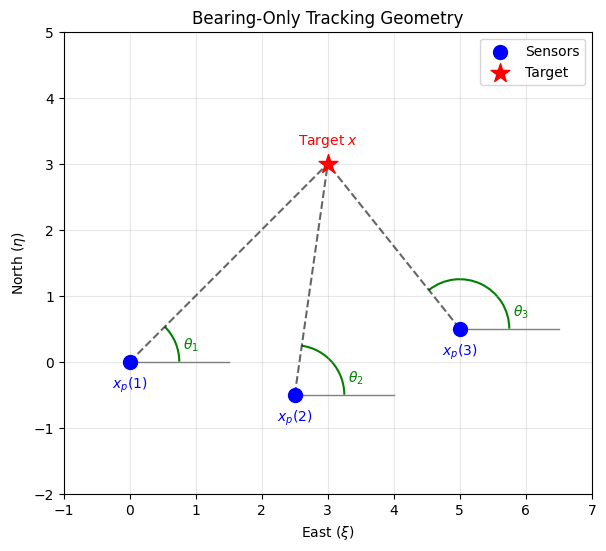

In [2]:
def draw_schematic():
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Coordinates from lecture notes example
    target = np.array([3, 3])
    sensors = np.array([[0, 0], [2.5, -0.5], [5, 0.5]])
    
    # Draw Sensors
    ax.scatter(sensors[:, 0], sensors[:, 1], c='blue', s=100, label='Sensors', zorder=5)
    for i, s in enumerate(sensors):
        ax.text(s[0], s[1]-0.4, f'$x_p({i+1})$', ha='center', color='blue')
        
        # Horizontal reference line
        ax.plot([s[0], s[0]+1.5], [s[1], s[1]], 'gray', lw=1)
        
        # Line of Sight
        ax.plot([s[0], target[0]], [s[1], target[1]], 'k--', alpha=0.6)
        
        # Angle Arc
        # Calculate angles for plotting arc correctly
        angle_rad = np.arctan2(target[1] - s[1], target[0] - s[0])
        angle_deg = np.degrees(angle_rad)
        
        arc = patches.Arc(s, 1.5, 1.5, angle=0, theta1=0, theta2=angle_deg, color='green', lw=1.5)
        ax.add_patch(arc)
        ax.text(s[0]+0.8, s[1]+0.2, rf'$\theta_{{{i+1}}}$', color='green')

    # Draw Target
    ax.scatter(target[0], target[1], c='red', marker='*', s=200, label='Target', zorder=5)
    ax.text(target[0], target[1]+0.3, r'Target $x$', ha='center', color='red')

    ax.set_aspect('equal')
    ax.set_xlabel(r'East ($\xi$)')
    ax.set_ylabel(r'North ($\eta$)')
    ax.set_title('Bearing-Only Tracking Geometry')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, 7)
    ax.set_ylim(-2, 5)
    plt.show()

draw_schematic()

## 4. Bearing Sensor Network Implementation

We define a class `BearingSensorNetwork` to handle the geometry, measurement generation, and Jacobian calculation.

In [3]:
class BearingSensorNetwork:
    def __init__(self, sensor_positions, noise_std_deg):
        """
        Initialize the sensor network.
        :param sensor_positions: Nx2 numpy array of sensor coordinates [x, y]
        :param noise_std_deg: Measurement noise standard deviation in degrees
        """
        self.sensors = sensor_positions
        self.num_sensors = len(sensor_positions)
        self.sigma = np.deg2rad(noise_std_deg)
        self.R = np.eye(self.num_sensors) * (self.sigma**2)
        
    def h(self, x):
        """
        Nonlinear measurement function h(x).
        Computes true bearings from each sensor to state x.
        """
        z_pred = np.zeros(self.num_sensors)
        for i in range(self.num_sensors):
            dx = x[0] - self.sensors[i, 0]
            dy = x[1] - self.sensors[i, 1]
            z_pred[i] = np.arctan2(dy, dx)
        return z_pred
    
    def measure(self, true_x):
        """
        Generate noisy measurements.
        """
        z_true = self.h(true_x)
        noise = np.random.normal(0, self.sigma, self.num_sensors)
        return z_true + noise
    
    def jacobian(self, x):
        """
        Calculate the Jacobian matrix H at state x.
        """
        H = np.zeros((self.num_sensors, 2))
        for i in range(self.num_sensors):
            dx = x[0] - self.sensors[i, 0]
            dy = x[1] - self.sensors[i, 1]
            r2 = dx**2 + dy**2
            
            # Derivatives of arctan(dy/dx)
            # d/dx = -dy / (dx^2 + dy^2)
            # d/dy = dx / (dx^2 + dy^2)
            H[i, 0] = -dy / r2
            H[i, 1] = dx / r2
        return H

## 5. Iterated Least Squares Algorithm

Now we implement the Gauss-Newton iteration loop.

In [4]:
def iterated_least_squares(network, z_meas, x_init, max_iter=20, tol=1e-6):
    """
    Perform ILS estimation.
    Returns:
        x_est: Final estimate
        P: Covariance matrix
        history: List of estimates at each iteration
    """
    x_curr = x_init.copy()
    history = [x_curr.copy()]
    
    for i in range(max_iter):
        H = network.jacobian(x_curr)
        z_pred = network.h(x_curr)
        
        # Innovation (residual)
        # NOTE: Be careful with angle wrapping! 
        # For simple cases it might not trigger, but robustness requires wrapping to [-pi, pi]
        dz = z_meas - z_pred
        dz = (dz + np.pi) % (2 * np.pi) - np.pi # Angle wrap
        
        # Gain / Update step
        # dx = (H^T R^-1 H)^-1 H^T R^-1 dz
        # This effectively solves the weighted linear least squares for the correction
        
        S_inv = inv(network.R)
        P = inv(H.T @ S_inv @ H)
        dx = P @ H.T @ S_inv @ dz
        
        x_curr = x_curr + dx
        history.append(x_curr.copy())
        
        if norm(dx) < tol:
            break
            
    return x_curr, P, np.array(history)

## 6. Simulation: Single Run Analysis

We will set up a scenario with 3 sensors and run a single estimation to visualize the convergence.

In [5]:
# Scenario Definition
sensor_pos = np.array([[0, 0], [15000, 5000], [30000, 0]])
target_true = np.array([20000, 20000])
params_noise_deg = 0.5

net = BearingSensorNetwork(sensor_pos, params_noise_deg)
z_meas = net.measure(target_true)

# Initial Guess (Intentional error)
x_init = np.array([10000.0, 10000.0])

# Run Estimation
x_est, P_est, history = iterated_least_squares(net, z_meas, x_init)

print(f"True Position: {target_true}")
print(f"Estimated Position: {x_est}")
print(f"Error: {norm(target_true - x_est):.2f} m")
print(f"Covariance Trace: {np.trace(P_est):.2f}")

True Position: [20000 20000]
Estimated Position: [19944.72794231 19940.01281722]
Error: 81.57 m
Covariance Trace: 75563.45


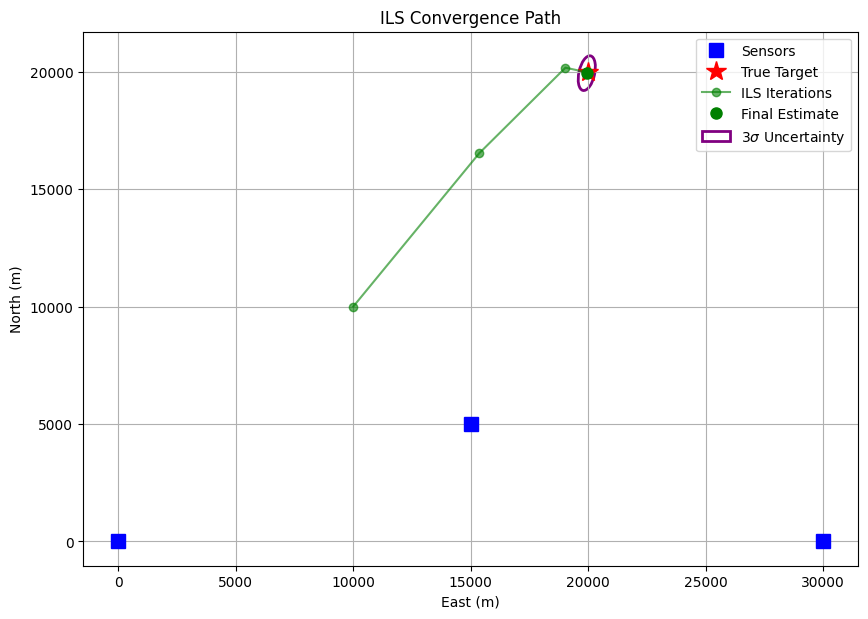

In [6]:
# Visualization of Convergence
def plot_results(sensors, target, history, P=None):
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Plot Sensors
    ax.plot(sensors[:,0], sensors[:,1], 'bs', label='Sensors', markersize=10)
    
    # Plot True Target
    ax.plot(target[0], target[1], 'r*', label='True Target', markersize=15)
    
    # Plot Estimation History
    ax.plot(history[:,0], history[:,1], 'g-o', label='ILS Iterations', alpha=0.6)
    ax.plot(history[-1,0], history[-1,1], 'go', label='Final Estimate', markersize=8)

    # Plot Error Ellipse (3-sigma)
    if P is not None:
        vals, vecs = np.linalg.eigh(P)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:,order]
        theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
        width, height = 3 * 2 * np.sqrt(vals) 
        ell = Ellipse(xy=history[-1], width=width, height=height, angle=theta, 
                      edgecolor='purple', lw=2, facecolor='none', label='3$\sigma$ Uncertainty')
        ax.add_patch(ell)
    
    ax.set_aspect('equal')
    ax.set_xlabel('East (m)')
    ax.set_ylabel('North (m)')
    ax.legend()
    ax.grid(True)
    ax.set_title('ILS Convergence Path')
    plt.show()

plot_results(sensor_pos, target_true, history, P_est)

## 7. Monte Carlo Analysis
Run $N$ simulations to verify that the estimator is unbiased and consistent with the theoretical covariance.

Theoretical Covariance (approx at true state):
[[14968.26976538 10766.65018212]
 [10766.65018212 61186.0851813 ]]

Monte Carlo Covariance:
[[15913.80478328 12617.16671771]
 [12617.16671771 58970.34565129]]


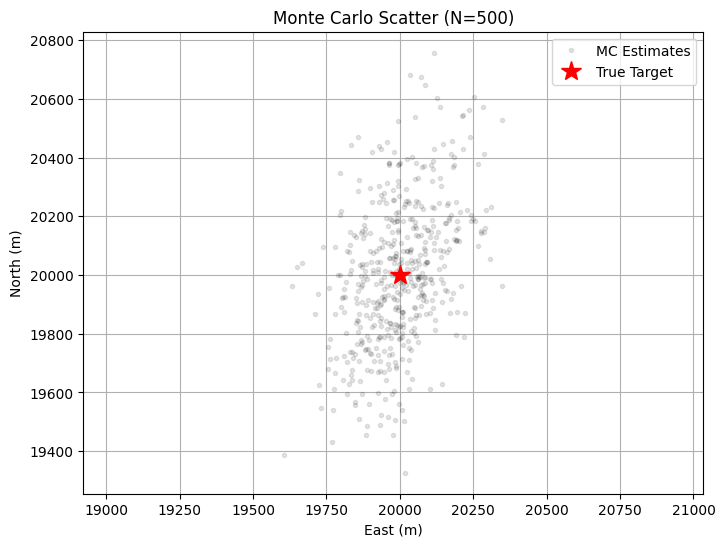

In [7]:
num_mc = 500
errors = []
estimates = []

for k in range(num_mc):
    z_k = net.measure(target_true)
    x_k, P_k, _ = iterated_least_squares(net, z_k, x_init)
    estimates.append(x_k)
    errors.append(x_k - target_true)

errors = np.array(errors)
estimates = np.array(estimates)

# Empirical Covariance
P_mc = np.cov(errors.T)

print("Theoretical Covariance (approx at true state):")
H_true = net.jacobian(target_true)
P_theo = inv(H_true.T @ inv(net.R) @ H_true)
print(P_theo)

print("\nMonte Carlo Covariance:")
print(P_mc)

# Plot MC scatter
plt.figure(figsize=(8,6))
plt.plot(estimates[:,0], estimates[:,1], 'k.', alpha=0.1, label='MC Estimates')
plt.plot(target_true[0], target_true[1], 'r*', markersize=15, label='True Target')
plt.axis('equal')
plt.title(f'Monte Carlo Scatter (N={num_mc})')
plt.xlabel('East (m)')
plt.ylabel('North (m)')
plt.grid(True)
plt.legend()
plt.show()

## 8. Student Exercise: Interactive GDOP Analysis

### Effect of Geometric Dilution of Precision (GDOP)
The geometry of the sensors relative to the target strongly influences the estimation accuracy. 
The uncertainty is inversely proportional to the "spread" of the bearing lines.

**Task:** Use the sliders below to move the 2nd sensor (middle one) horizontally. Observe how the **Error Ellipse** changes.
1.  What happens when the sensors are nearly collinear with the target?
2.  What is the optimal geometry?

In [8]:
from IPython.display import display, clear_output

def interactive_geometry(s2_x_offset=0, s2_y_offset=0):
    # CRITICAL FIX: Clear previous output before drawing new plot
    clear_output(wait=True)
    
    # Base positions
    target = np.array([20000, 20000])
    s1 = np.array([0, 0])
    s3 = np.array([30000, 0])
    
    # Movable Sensor 2 (starts at [15000, 5000])
    s2 = np.array([15000 + s2_x_offset, 5000 + s2_y_offset])
    
    current_sensors = np.array([s1, s2, s3])
    
    # Create network and compute theoretical covariance
    # We don't need to simulate noise, just compute P = (H^T R^-1 H)^-1
    temp_net = BearingSensorNetwork(current_sensors, 0.5)
    H = temp_net.jacobian(target)
    P = inv(H.T @ inv(temp_net.R) @ H)
    
    # Visualization
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.plot(current_sensors[:,0], current_sensors[:,1], 'bs', markersize=10)
    ax.plot(target[0], target[1], 'r*', markersize=15)
    
    # Draw Lines of Sight
    for s in current_sensors:
        ax.plot([s[0], target[0]], [s[1], target[1]], 'k--', alpha=0.3)
    
    # Draw Ellipse
    vals, vecs = np.linalg.eigh(P)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:,order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    
    # 3-sigma Ellipse
    width_3s, height_3s = 3 * 2 * np.sqrt(vals)
    ell_3s = Ellipse(xy=target, width=width_3s, height=height_3s, angle=theta, 
                  edgecolor='purple', lw=1, facecolor='purple', alpha=0.1, label=r'3$\sigma$')
    ax.add_patch(ell_3s)
    
    # 1-sigma Ellipse
    width_1s, height_1s = 2 * np.sqrt(vals)
    ell_1s = Ellipse(xy=target, width=width_1s, height=height_1s, angle=theta, 
                  edgecolor='red', lw=2, facecolor='none', linestyle='--', label=r'1$\sigma$')
    ax.add_patch(ell_1s)
    
    # Calculate GDOP metric (sqrt(trace(P)))
    gdop = np.sqrt(np.trace(P))
    ax.set_title(f'Geometry Effect. Position Error (RMSE prediction): {gdop:.2f} m')
    
    ax.set_xlim(-5000, 45000)
    ax.set_ylim(-5000, 25000)
    ax.set_aspect('equal')
    ax.grid(True)
    ax.legend()
    plt.show()

# Create sliders
interact(interactive_geometry, 
         s2_x_offset=widgets.FloatSlider(min=-15000, max=15000, step=1000, value=0, description='S2 X Offset'),
         s2_y_offset=widgets.FloatSlider(min=-10000, max=30000, step=1000, value=0, description='S2 Y Offset'));

interactive(children=(FloatSlider(value=0.0, description='S2 X Offset', max=15000.0, min=-15000.0, step=1000.0…

### Analysis: Answering the Exercise Questions

#### Q1 — What happens when sensors are nearly collinear with the target?
When all sensors lie roughly on the same line (relative to the target), all bearing lines become nearly parallel. The information matrix $\mathbf{H}^T\mathbf{R}^{-1}\mathbf{H}$ becomes nearly singular, and the covariance $\mathbf{P}$ explodes in the direction perpendicular to that line → huge GDOP.

#### Q2 — What is the optimal geometry?
The optimal placement maximises the determinant of $\mathbf{H}^T\mathbf{R}^{-1}\mathbf{H}$ (D-optimal design). For three sensors this is achieved when the bearing lines subtend equal angles (≈ 120° apart), i.e. an **equilateral triangle** around the target. We verify this numerically below with a GDOP sweep and heatmap.

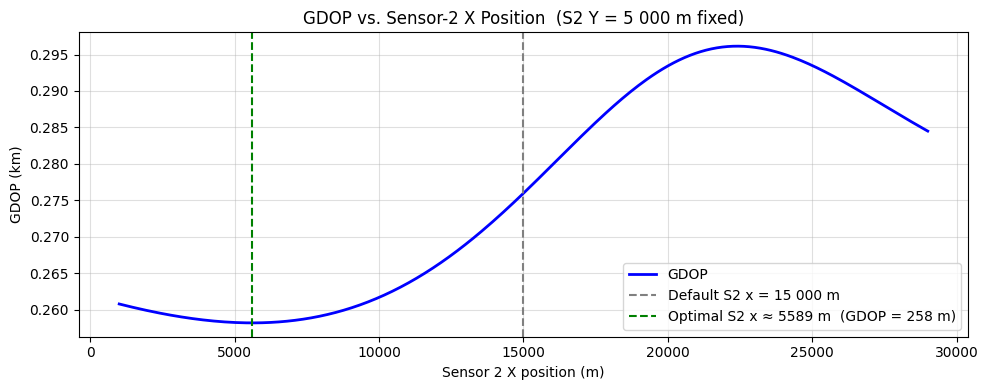

Minimum GDOP = 258.2 m  at S2_x ≈ 5589 m


In [9]:
# ── GDOP vs. Sensor-2 X-position (S2 Y fixed at 5000 m) ─────────────────
target_g  = np.array([20000, 20000])
s1_g      = np.array([0, 0])
s3_g      = np.array([30000, 0])

x_offsets  = np.linspace(-14000, 14000, 300)
gdop_vals  = []

for dx in x_offsets:
    s2_g    = np.array([15000 + dx, 5000])
    sensors = np.array([s1_g, s2_g, s3_g])
    net_g   = BearingSensorNetwork(sensors, 0.5)
    H_g     = net_g.jacobian(target_g)
    try:
        P_g  = inv(H_g.T @ inv(net_g.R) @ H_g)
        gdop = np.sqrt(np.trace(P_g))
    except np.linalg.LinAlgError:
        gdop = np.nan
    gdop_vals.append(gdop)

gdop_vals = np.array(gdop_vals)
x_abs     = 15000 + x_offsets
min_idx   = np.nanargmin(gdop_vals)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(x_abs, gdop_vals / 1e3, 'b-', lw=2, label='GDOP')
ax.axvline(15000, color='gray',  ls='--', label='Default S2 x = 15 000 m')
ax.axvline(x_abs[min_idx], color='green', ls='--',
           label=f'Optimal S2 x ≈ {x_abs[min_idx]:.0f} m  (GDOP = {gdop_vals[min_idx]:.0f} m)')
ax.set_xlabel('Sensor 2 X position (m)')
ax.set_ylabel('GDOP (km)')
ax.set_title('GDOP vs. Sensor-2 X Position  (S2 Y = 5 000 m fixed)')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout(); plt.show()

print(f'Minimum GDOP = {gdop_vals[min_idx]:.1f} m  '
      f'at S2_x ≈ {x_abs[min_idx]:.0f} m')


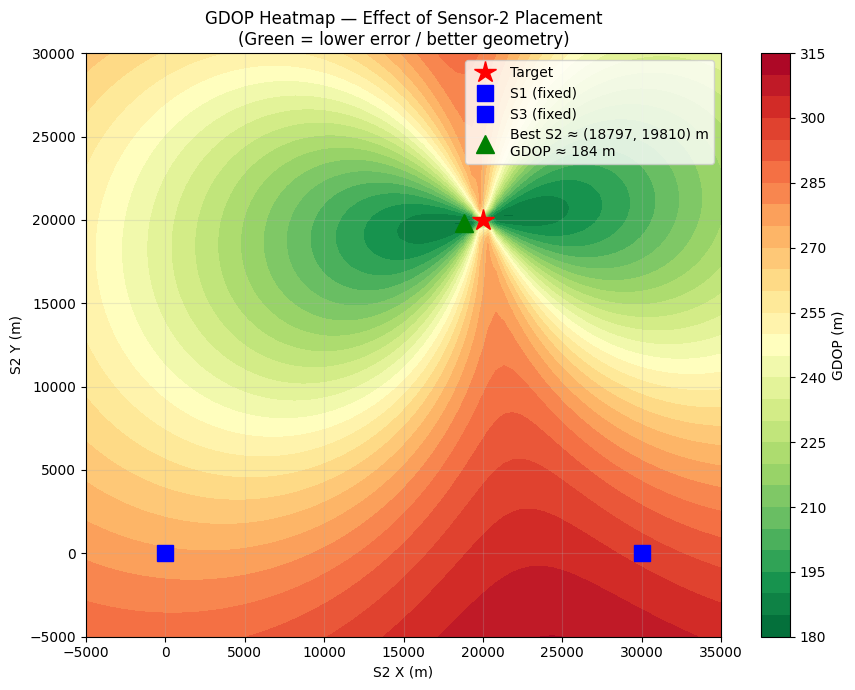

In [10]:
# ── 2-D GDOP heatmap: sweep S2 over a grid ───────────────────────────────
NX, NY = 80, 80
x_range = np.linspace(-5000, 35000, NX)
y_range = np.linspace(-5000, 30000, NY)
XX, YY  = np.meshgrid(x_range, y_range)
GDOP_MAP = np.full_like(XX, np.nan)

for i in range(NY):
    for j in range(NX):
        s2_h    = np.array([XX[i, j], YY[i, j]])
        sensors = np.array([s1_g, s2_h, s3_g])
        net_h   = BearingSensorNetwork(sensors, 0.5)
        H_h     = net_h.jacobian(target_g)
        try:
            P_h  = inv(H_h.T @ inv(net_h.R) @ H_h)
            GDOP_MAP[i, j] = np.sqrt(np.trace(P_h))
        except Exception:
            pass

fig, ax = plt.subplots(figsize=(9, 7))
cp = ax.contourf(XX, YY, np.clip(GDOP_MAP, 0, 6000),
                 levels=30, cmap='RdYlGn_r')
plt.colorbar(cp, ax=ax, label='GDOP (m)')

ax.plot(*target_g, 'r*',  markersize=16, zorder=5, label='Target')
ax.plot(*s1_g,     'bs',  markersize=11, zorder=5, label='S1 (fixed)')
ax.plot(*s3_g,     'bs',  markersize=11, zorder=5, label='S3 (fixed)')

best_idx = np.unravel_index(np.nanargmin(GDOP_MAP), GDOP_MAP.shape)
bx, by   = XX[best_idx], YY[best_idx]
ax.plot(bx, by, 'g^', markersize=13, zorder=5,
        label=f'Best S2 ≈ ({bx:.0f}, {by:.0f}) m\nGDOP ≈ {GDOP_MAP[best_idx]:.0f} m')

ax.set_xlabel('S2 X (m)'); ax.set_ylabel('S2 Y (m)')
ax.set_title('GDOP Heatmap — Effect of Sensor-2 Placement\n(Green = lower error / better geometry)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.25)
plt.tight_layout(); plt.show()


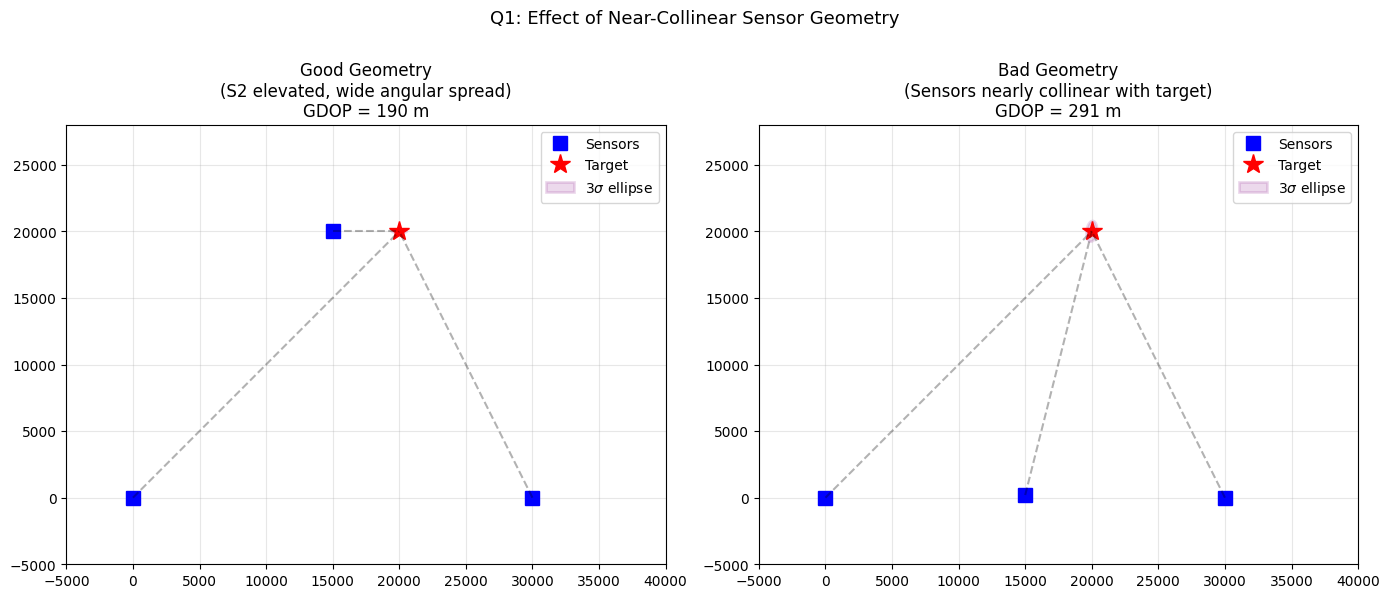

Good (elevated)   GDOP =    190.0 m
Bad  (collinear)  GDOP =    291.0 m

Ratio (bad / good): 1.5x worse


In [11]:
# ── Side-by-side: good vs. nearly-collinear geometry (Q1) ────────────────
s2_good = np.array([15000, 20000])   # S2 at target height  → wide angular spread
s2_bad  = np.array([15000,   200])   # S2 near x-axis       → nearly collinear

cases = [
    (s2_good, 'Good Geometry\n(S2 elevated, wide angular spread)'),
    (s2_bad,  'Bad Geometry\n(Sensors nearly collinear with target)'),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (s2_c, title) in zip(axes, cases):
    sensors_c = np.array([s1_g, s2_c, s3_g])
    net_c     = BearingSensorNetwork(sensors_c, 0.5)
    H_c       = net_c.jacobian(target_g)
    P_c       = inv(H_c.T @ inv(net_c.R) @ H_c)
    gdop_c    = np.sqrt(np.trace(P_c))

    ax.plot(sensors_c[:, 0], sensors_c[:, 1], 'bs', markersize=10, label='Sensors')
    ax.plot(*target_g, 'r*', markersize=15, label='Target')
    for s in sensors_c:
        ax.plot([s[0], target_g[0]], [s[1], target_g[1]], 'k--', alpha=0.3)

    # 3-sigma error ellipse
    vals_e, vecs_e = np.linalg.eigh(P_c)
    order_e  = vals_e.argsort()[::-1]
    vals_e   = vals_e[order_e]; vecs_e = vecs_e[:, order_e]
    theta_e  = np.degrees(np.arctan2(*vecs_e[:, 0][::-1]))
    w3, h3   = 3 * 2 * np.sqrt(vals_e)
    ell = Ellipse(xy=target_g, width=w3, height=h3, angle=theta_e,
                  edgecolor='purple', lw=2, facecolor='purple',
                  alpha=0.15, label=r'3$\sigma$ ellipse')
    ax.add_patch(ell)

    ax.set_xlim(-5000, 40000); ax.set_ylim(-5000, 28000)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nGDOP = {gdop_c:.0f} m')
    ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle('Q1: Effect of Near-Collinear Sensor Geometry', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

# Numerical summary
gdops = []
for s2_c, lbl in [(s2_good, 'Good (elevated) '), (s2_bad, 'Bad  (collinear)')]:
    net_c  = BearingSensorNetwork(np.array([s1_g, s2_c, s3_g]), 0.5)
    H_c    = net_c.jacobian(target_g)
    P_c    = inv(H_c.T @ inv(net_c.R) @ H_c)
    gdops.append(np.sqrt(np.trace(P_c)))
    print(f'{lbl}  GDOP = {gdops[-1]:8.1f} m')
print(f'\nRatio (bad / good): {gdops[1]/gdops[0]:.1f}x worse')


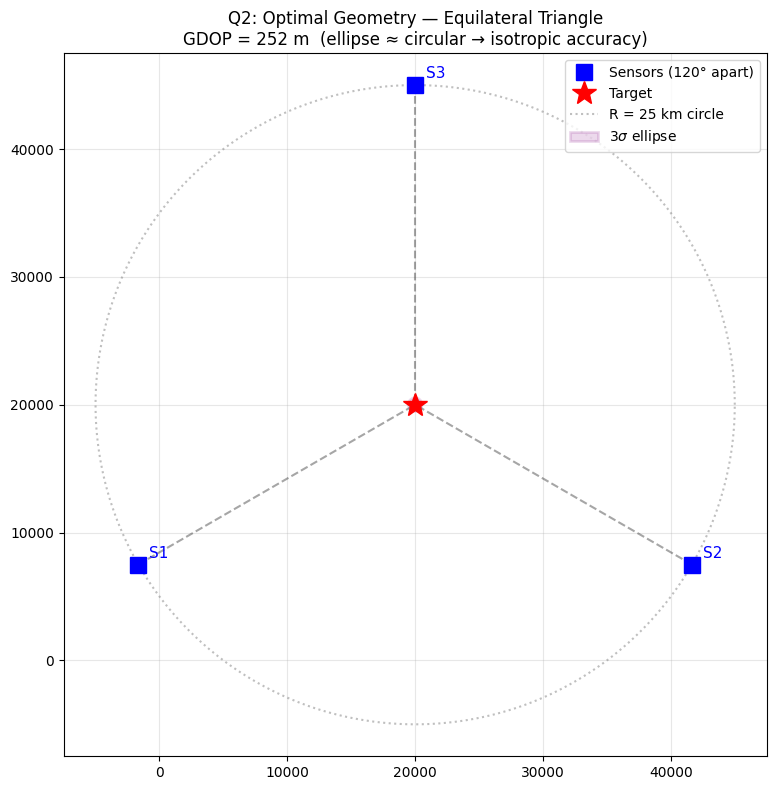

Optimal GDOP (equilateral, R=25 km): 251.9 m
sigma_x = 178.1 m,  sigma_y = 178.1 m  (nearly equal -> isotropic)


In [12]:
# ── Q2: Optimal geometry — equilateral-triangle placement ────────────────
# Place sensors on a circle of radius R centred on the target, 120° apart.
R_opt    = 25000          # stand-off radius (m)
angles   = np.radians([210, 330, 90])   # 120° apart
sensors_opt = target_g + R_opt * np.column_stack([np.cos(angles), np.sin(angles)])

net_opt  = BearingSensorNetwork(sensors_opt, 0.5)
H_opt    = net_opt.jacobian(target_g)
P_opt    = inv(H_opt.T @ inv(net_opt.R) @ H_opt)
gdop_opt = np.sqrt(np.trace(P_opt))

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(sensors_opt[:, 0], sensors_opt[:, 1], 'bs', markersize=12,
        zorder=5, label='Sensors (120° apart)')
for i, s in enumerate(sensors_opt):
    ax.annotate(f'S{i+1}', s, textcoords='offset points',
                xytext=(8, 5), fontsize=11, color='blue')
    ax.plot([s[0], target_g[0]], [s[1], target_g[1]], 'k--', alpha=0.35)
ax.plot(*target_g, 'r*', markersize=18, zorder=5, label='Target')

# Stand-off circle
th = np.linspace(0, 2 * np.pi, 300)
ax.plot(target_g[0] + R_opt * np.cos(th),
        target_g[1] + R_opt * np.sin(th),
        'gray', ls=':', alpha=0.5, label=f'R = {R_opt/1e3:.0f} km circle')

# 3-sigma ellipse (should be nearly circular)
vals_o, vecs_o = np.linalg.eigh(P_opt)
order_o  = vals_o.argsort()[::-1]
vals_o   = vals_o[order_o]; vecs_o = vecs_o[:, order_o]
theta_o  = np.degrees(np.arctan2(*vecs_o[:, 0][::-1]))
w3o, h3o = 3 * 2 * np.sqrt(vals_o)
ell_o = Ellipse(xy=target_g, width=w3o, height=h3o, angle=theta_o,
                edgecolor='purple', lw=2, facecolor='purple',
                alpha=0.15, label=r'3$\sigma$ ellipse')
ax.add_patch(ell_o)

ax.set_aspect('equal')
ax.set_title(f'Q2: Optimal Geometry — Equilateral Triangle\n'
             f'GDOP = {gdop_opt:.0f} m  (ellipse ≈ circular → isotropic accuracy)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Optimal GDOP (equilateral, R={R_opt/1e3:.0f} km): {gdop_opt:.1f} m')
print(f'sigma_x = {np.sqrt(P_opt[0,0]):.1f} m,  '
      f'sigma_y = {np.sqrt(P_opt[1,1]):.1f} m  '
      f'(nearly equal -> isotropic)')
